# South Fork of the American River Near Kyburz
Rim Inlflows for SF of Amer R. nr Kyburz are calculated as (Unimpaired flows for USGS 11439501 gage - upstream inflows at Caples, Silver, Aloha Lakes and Inflow to Pyramid Creek ) * a watershed factor
The Watershed factor = SFA066 Basin Area for GIS Analysis / Total Area Upstream of USGS 11439501 (Sum of the areas for SFA066, SFA076 and SLF 009 basins)

1. Import New Data, as needed
* USGS
*CDEC


2. Calculate and gapfill datasets needed to unimpare flows
  *Reservoir Evaporation (Caples, Silver, and Aloha Lakes) 
  *Gapfilling


3. Unimpair Data
  *USGS 11439501 SF American R Near Kyburz Total Flow CA, that's used to extended the French Meadows Gage
  *To unimpare USGS 11439501
    -Add Caples Storage
    -Add Caples Evporation
    -Add Aloha Storage 
    -Add Aloha Evaporation
    -Subtract Echo Lake Conduit (Echo Lake flows are conveyed into the SF American via conveyance system), these flows are accounted for in I_ECHOL

4. Extend/Fill the Unimpaired Data using S-Curve Disagg 
  *Flows for USGS 11439501 are mostly complete, only 1922 is missing
  *Extended using the American R at Folsom Full Natural Flow data from CDEC

5. Calculate the final rim inflow 
  *Rim Inflow for SFA066 = Unimpaired flow for USGS 11439501 SF American 11439501 - I_CAPLS, I_SILVR, I_ALOHA, and I_PYR001 flows



In [1]:

# Import needed packages and extenion, impairment, rim inflow, and evaporation functions

import os

os.chdir("C:/Users/lthatch/GitHub/calsim-extension")

from extension_functions import *
from unimpairment_functions import *
from rim_inflow_functions import *
from evaporation_functions import *
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Traceback (most recent call last):
  File "c:\Users\lthatch\AppData\Local\miniforge3\envs\extension\Lib\site-packages\pydsstools\core\raster_grid.py", line 16, in <module>
    import rasterio
ModuleNotFoundError: No module named 'rasterio'


In [2]:
# Previous Spreadsheet file for French Meadows to compare results with
s_old_spreadsheet_fn = 'C:/Users/lthatch/OneDrive - DOI/CalSim/SVComposer/Incoming_SV_TOC_fromDWRBox/Incoming/Inflow Spreadsheets/Sacramento/CS3_I_SFA066_Rev2022G.xlsm'

In [3]:
# Model Parameters and Input Data from the Previous Extension
i_final_year = 2021 # end of previous extension

# this holds the already extended evap rates
s_evap_dss_path = r".\Inputs\evaporation_rates.dss"


# this holds the USGS data (sometimes gap filled) from the previous extension
s_previous_data = r".\Inputs\2022_extension_data.csv"

# time range to pull USGS data for
s_start_date = '2021-10-01'
s_end_date = '2024-09-30'

Pulled data for USGS stations:  ['11435900', '11436950', '11434500', '11439501']
Did not pull data for USGS stations:  ['11434900']
Pulled CDEC data for: AMF


Text(0.5, 1.0, 'Combined Previous and New Gage Data')

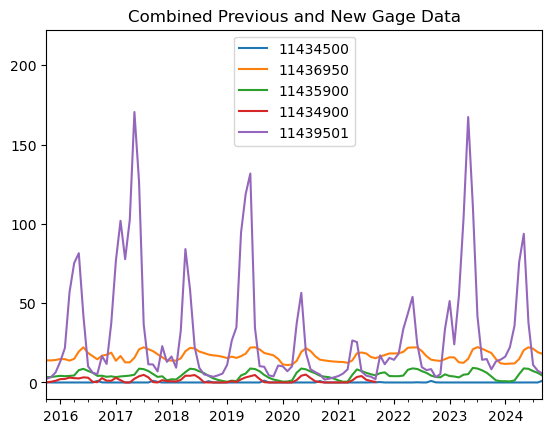

In [4]:
# Import new data

# USGS Data
# 11435900 Silver Lake Storage
# 11436950 Caples Lake Storage
# 11434900 Lake Aloha Storage
# 11434500 Echo Lake Conduit
# 11435500 SF American R at Kyburz

# pull USGS data
sl_usgs_stations = ['11434500','11436950','11435900','11434900','11439501']
df_usgs_data_original, df_usgs_data_monthly_taf = pull_usgs_data(sl_usgs_stations, s_start_date, s_end_date)

# CDEC Data
# Data will be extended for the 1922 using AMF FNF from CDEC

# pull the cdec data
sl_cdec_stations = ["AMF"]
df_cdec_data_original, df_cdec_data_monthly_taf = pull_cdec_data(sl_cdec_stations, s_start_date, s_end_date)

# combine all the gauge data
df_gauge_data_original = pd.merge(df_usgs_data_original, df_cdec_data_original, how='outer', left_index=True, right_index=True)
df_gauge_data_monthly_taf = pd.merge(df_usgs_data_monthly_taf, df_cdec_data_monthly_taf, how='outer', left_index=True, right_index=True)

#df_gauge_data_monthly_taf.rename(columns={'BEV': 'YB90'}, inplace=True)

# combine the new data with the previous data
df_full_data = read_previous_data(s_previous_data, df_gauge_data_monthly_taf)

# plot data for location
df_full_data[sl_usgs_stations].plot()
plt.xlim(pd.to_datetime('2015-10-01'),pd.to_datetime(s_end_date))
plt.title('Combined Previous and New Gage Data')

In [ ]:
# Data is missing in a few of the USGS gage records, Gap fill the data sets as needed
# Note, these data was previously gapfilled in the spreadhseets, so the gapfilled data will match the existing if it's prior to the start of the extension
#df_full_data_preGapFill = df_full_data.copy()
#gap_fill(df_full_data, {'11435900': [1923],
#                        '11436950': [1924],
#                        '11434900': list(range(1929, 1933)) + list(range(2022,2025))},i_final_year) # extend Aloha storage with monthly averages for now, missing data

# gapfill caples storage a little different, these values were just set to zero
df_full_data.loc[(df_full_data['11436950'].isna()) & (df_full_data.index.year >= 1922) & (df_full_data.index.year <= 1924),'11436950'] = 0
df_full_data.loc[(df_full_data['11435900'].isna()) & (df_full_data.index.year >= 1922) & (df_full_data.index.year < 1923),'11435900'] = 0

gap_fill(df_full_data, { #'11436950': [1922, 1923, 1924],
                        '11435900': [1923], '11434900': list(range(1929, 1933))},
            i_final_year)

# the datasets are the same, as the previous dataset was gapfilled w/ monthly averages, python and previous method yield the same result

In [6]:
# Calculate evporation data neded for these unimpairment locations - note the evaporation variables are named for the gages that use them to unimpair flows
# evaporation functions for each reservoir are in the 'evaporation_functions.py'

# Evaporation rates are already calculated for French Meadows Caples Lake, Silver Lake, and Lake Aloha, 
# these functions are needed to estimate volumes using associated area capacity tables which are included in the 'Area Capcities/' Folder


calc_evap_11436950(s_evap_dss_path, df_full_data) # Caples lake 
calc_evap_11435900(s_evap_dss_path, df_full_data) # Silver Lake
calc_evap_11434900(s_evap_dss_path, df_full_data) # Lake Aloha

In [7]:
# Unimpair the data
df_unimpaired_data = pd.DataFrame()

print("Calculating unimpaired flows...")

df_unimpaired_data['11439501'] = unimpaired_11439501(df_full_data) 

# drop the first row which is only for calculating storage differences
df_unimpaired_data.drop(index=df_unimpaired_data.index[0], inplace=True)

# redistribute negatives - negatives are set to zero and the negative flows are redistributed to the rest of the wy propotionaly based on monthly flow, keeping the total annual flow the same
df_pos_unimpaired_data = remove_negatives_timeseries(df_unimpaired_data)

Calculating unimpaired flows...


In [8]:
# Extend Dataset

# create dataframe for extension
df_extended_data = pd.DataFrame()
df_synthetic_data = pd.DataFrame()

# extend all with the s-curve disaggregation
extend_data(df_full_data['AMF'], df_pos_unimpaired_data['11439501'], df_extended_data, df_synthetic_data, 1923, i_final_year, False, '11439501', i_final_year=i_final_year)

In [9]:
# Calculate Rim Inflows 
# Rim inflows for SFA066 are equal to the unimpared gage data, minus upstream inflows

# these inflows were calculated in the full calculate_rim_inflows.py sheet
# For this example, example we'll pull in previous rim inflow data from the Ouptut folder
df_prev_rim_inflows = pd.read_csv('Outputs/rim_inflows.csv',index_col=0)

df_rim_inflows = df_prev_rim_inflows[['I_CAPLS','I_SILVR','I_ALOHA','I_PYR001']].copy()
df_rim_inflows.index = pd.to_datetime(df_rim_inflows.index)

# calculate rim inflows for this location, it will add it to the df_rim_inflows dataframe
I_SFA066(df_extended_data, df_rim_inflows)

<Axes: >

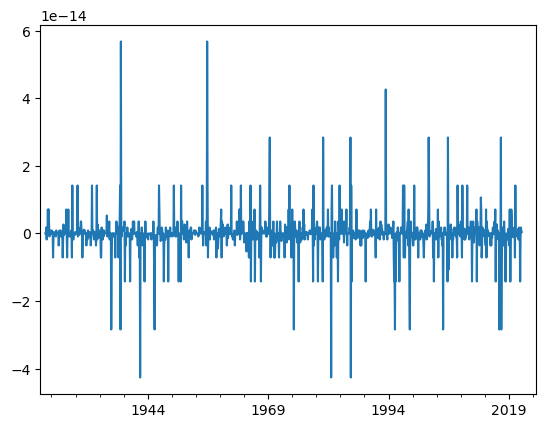

In [14]:
# Compare Results from Python with the Previous Excel Spreadsheet
#

# Pull all python variables used for the unimpairment and extension to compare 

l_variables = []

# gage data
l_variables.append(df_full_data[['11439501','11436950','11435900','11434900']])

# grab storages
l_variables.append(df_full_data['11436950'] - df_full_data['11436950'].shift(1)) # Caples Lake
l_variables.append(df_full_data['11435900'] - df_full_data['11435900'].shift(1)) # Silver Lake
l_variables.append(df_full_data['11434900'] - df_full_data['11434900'].shift(1)) # Silver Lake

# grab evaporation
l_variables.append(df_full_data['11436950_evap']) # Caples Lake Evap
l_variables.append(df_full_data['11435900_evap']) # Silver Lake Evap
l_variables.append(df_full_data['11434900_evap']) # Aloha Evap

# echo
l_variables.append(df_full_data['11434500']) # Echo conduit

# Unimpaired Data
l_variables.append(df_unimpaired_data['11439501']) #SF AMERICAN R NR KYBURZ TOTAL FLOW CA
# l_variables.append(df_full_data['AMF']) # data used for the extension, full natural flows on the american MF from CDEC

# extended data
l_variables.append(df_extended_data['11439501'])

# final rim inflow
l_variables.append(df_rim_inflows['I_SFA066'])


df_all_unimp_data = pd.concat(l_variables,axis=1)
df_all_unimp_data.columns = ['GageData','CaplesSto','SilverSto','AlohaSto','CaplesStoChng','SilverStoChng','AlohaStoChng',\
                             'CaplesEvap','SilverEvap','AlohaEvap','EchoConduit',\
                                'GageData_Unimp','GageData_Unimp_Pos_Extended','I_SFA066']

df_all_unimp_data['GageData_Unimp_check'] = df_all_unimp_data['GageData'] + df_all_unimp_data['CaplesStoChng']+ df_all_unimp_data['SilverStoChng']+ df_all_unimp_data['AlohaStoChng'] \
    + df_all_unimp_data['CaplesEvap']+ df_all_unimp_data['SilverEvap']+ df_all_unimp_data['AlohaEvap'] \
    - df_all_unimp_data['EchoConduit'] # this same calculation is included in the unimpairment function 'unimpaired_11439501'

# double check unimpairment function matches as expected, there should be no difference (or small rounding differences)
df_all_unimp_data['Diff'] = df_all_unimp_data['GageData_Unimp_check'] - df_all_unimp_data['GageData_Unimp']
df_all_unimp_data['Diff'].plot()

# confirmed it's calculating as expected. 

C:\Users\lthatch\AppData\Local\Temp\1\ipykernel_41948\1129565589.py:28: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_excel_all = pd.concat(l_spreadsheet_dfs,axis=1)


<Axes: >

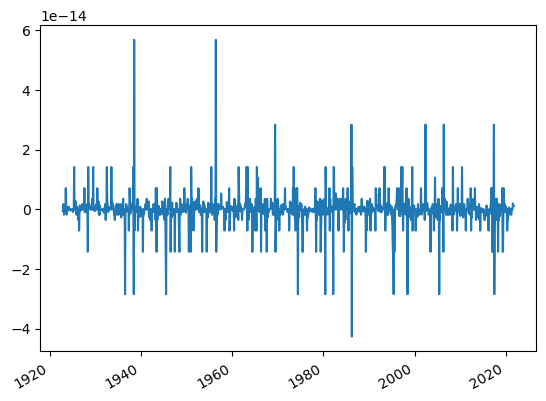

In [ ]:
# grab all the same data from the excel sheet
# Import the data from the spreadsheets
l_column_names = ['CaplesEvap','SilverEvap','AlohaEvap','CaplesSto','SilverSto','AlohaSto','EchoConduit',\
                  'GageData','GageData_Unimp','GageData_Unimp_Pos_Extended','I_SFA066']
l_sheet = ['Caples Evaporation','Silver Evaporation','Aloha Evaporation','Extended Caples Storage','Extended Silver Storage','Aloha Storage Infilled','Echo Lake Conduit 11434500',\
           'SF American 11439501','Unimp SF American 11439501','MODELA','SV INPUT']
l_usecols = ['B:D'] * (len(l_sheet)-2) + ['AF:AG'] + ['A:D']
l_fn = [s_old_spreadsheet_fn] * len(l_sheet)
l_skiprows = [14] * (len(l_sheet)-2) + [7] + [17]

l_spreadsheet_dfs = []
for s_colname,s_sheet,s_usecols,s_fn,i_skiprows in zip(l_column_names,l_sheet,l_usecols,l_fn,l_skiprows):

    # read the data from the spreadsheet
    df_excel_spreadsheet = pd.read_excel(s_fn,
                                    sheet_name = s_sheet,
                                    skiprows= i_skiprows,
                                    usecols=s_usecols,
                                    index_col=0)
    
    if s_colname[-3:] == 'Sto': # storage sheets are a little different
        df_excel_spreadsheet.columns = ['cfs','TAF']
    if s_colname[:2] == 'I_': # inflow location
        df_excel_spreadsheet.columns = ['year','month','TAF']
    df_excel_spreadsheet.loc[df_excel_spreadsheet['TAF']==-901,'TAF'] = np.nan # remove -901 values
    l_spreadsheet_dfs.append(df_excel_spreadsheet['TAF'])

df_excel_all = pd.concat(l_spreadsheet_dfs,axis=1)
df_excel_all.columns = l_column_names

# calculate storage changes
for s_sto in ['CaplesSto','SilverSto','AlohaSto']:
    df_excel_all[s_sto + 'Chng'] = df_excel_all[s_sto] - df_excel_all[s_sto].shift(1)

# Again just double checking that the spreadsheet is caulcing unimpaired flows as expected, 
df_excel_all['GageData_Unimp_check'] = df_excel_all['GageData'] + df_excel_all['CaplesStoChng']+ df_excel_all['SilverStoChng']+ df_excel_all['AlohaStoChng'] \
    + df_excel_all['CaplesEvap']+ df_excel_all['SilverEvap']+ df_excel_all['AlohaEvap'] \
    - df_excel_all['EchoConduit']
df_excel_all['Diff'] =df_excel_all['GageData_Unimp_check'] - df_excel_all['GageData_Unimp']
df_excel_all['Diff'].plot()

Maximum difference for CaplesEvap is 3.458777969589377e-08 on 1963-08-31 00:00:00, with a % difference of 7.752586323082655e-06
Maximum difference for SilverEvap is 0.002466196551814473 on 1923-03-31 00:00:00, with a % difference of 5.5200119202283835
Maximum difference for AlohaEvap is 0.0012610656014590826 on 1929-10-31 00:00:00, with a % difference of 2.8060959581081026
Maximum difference for CaplesSto is 0.0 on 1922-01-31 00:00:00, with a % difference of nan
Maximum difference for SilverSto is 0.7000714285714287 on 1923-01-31 00:00:00, with a % difference of 89.46599726152444
Maximum difference for AlohaSto is 0.011455433848797214 on 1929-09-30 00:00:00, with a % difference of 3.3809501321503137
Maximum difference for CaplesStoChng is 0.0 on 1922-02-28 00:00:00, with a % difference of nan
Maximum difference for SilverStoChng is 1.0615637755102043 on 1923-02-28 00:00:00, with a % difference of 87.32658307538956
Maximum difference for AlohaStoChng is 0.011455433848797242 on 1929-10-3

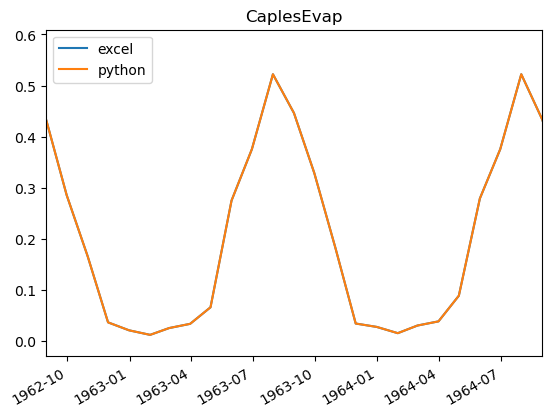

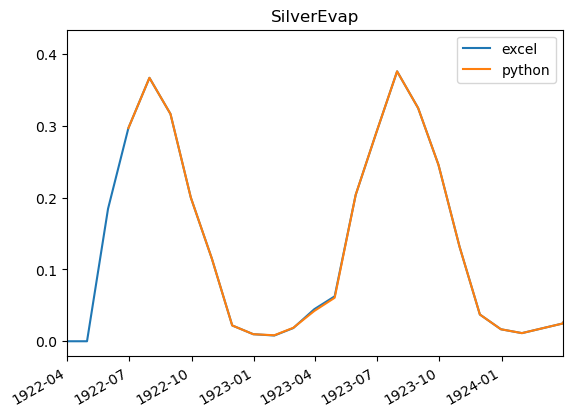

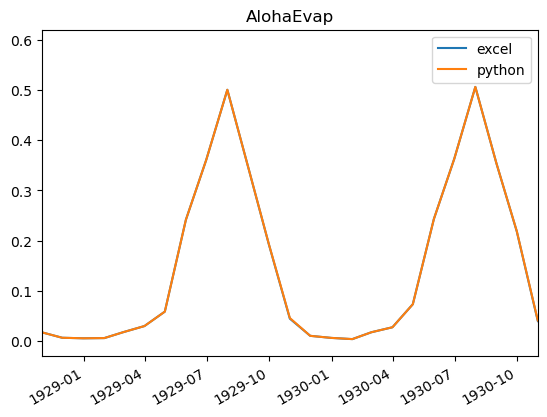

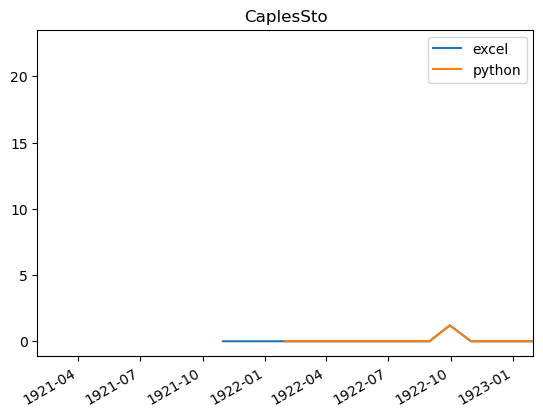

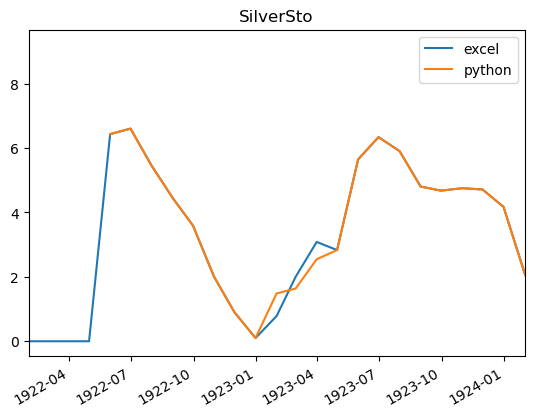

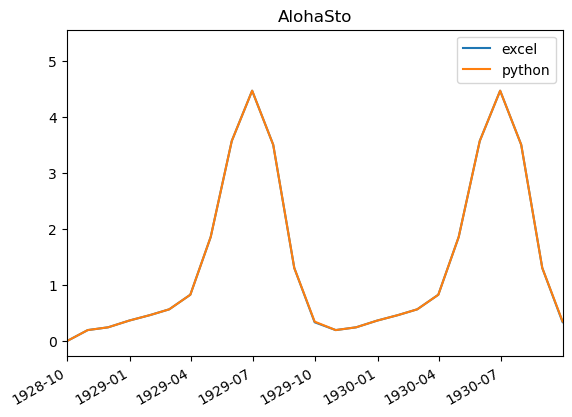

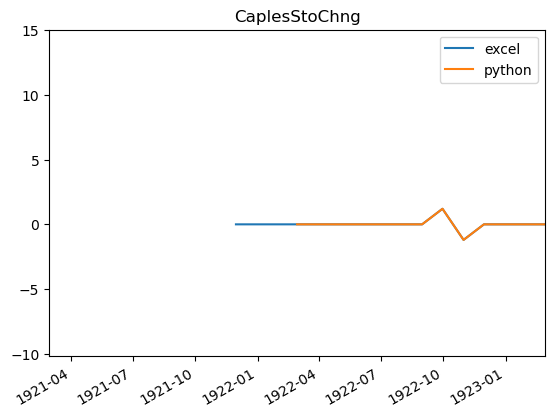

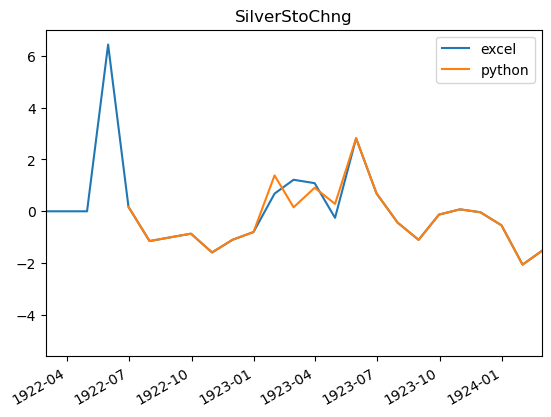

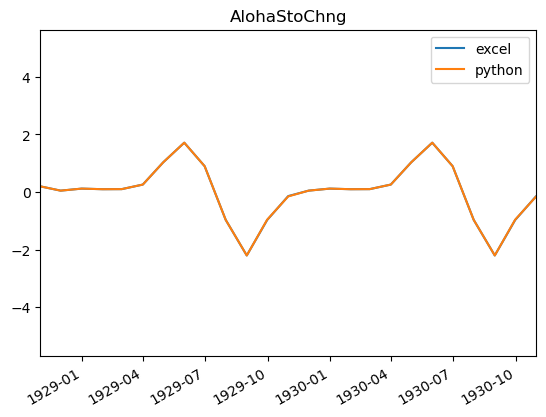

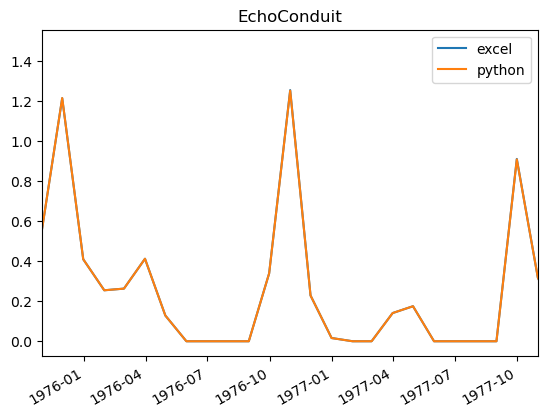

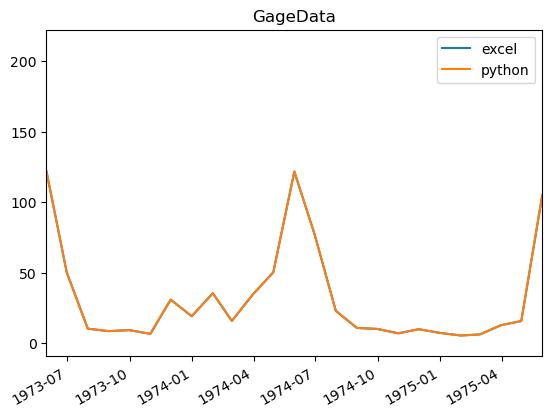

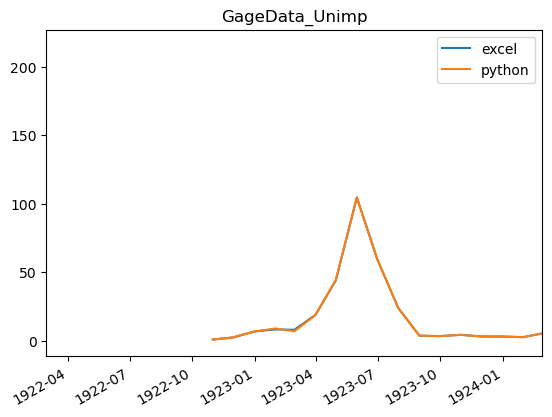

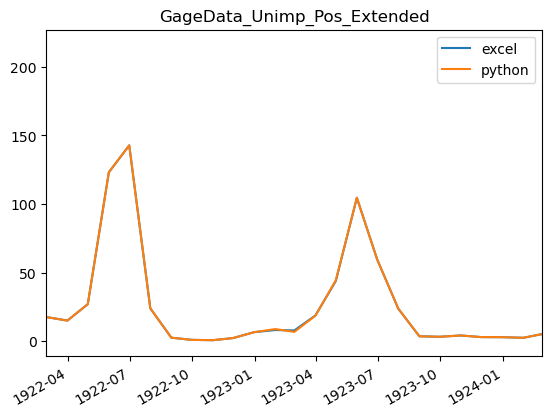

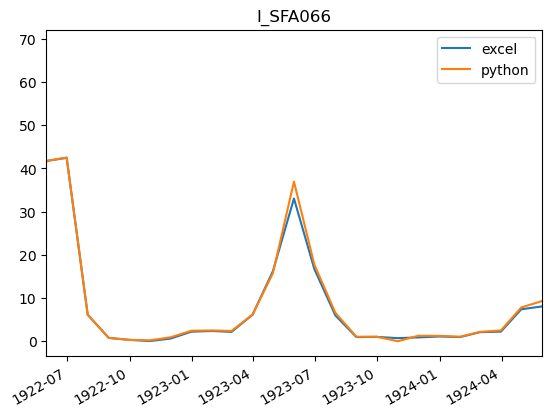

In [12]:
# Plot a comparison
l_plt_vars =  ['CaplesEvap','SilverEvap','AlohaEvap','CaplesSto','SilverSto','AlohaSto',\
               'CaplesStoChng','SilverStoChng','AlohaStoChng','EchoConduit',\
                'GageData','GageData_Unimp','GageData_Unimp_Pos_Extended','I_SFA066']

for s_plt_var in l_plt_vars:

    df_compare = pd.concat([df_all_unimp_data[s_plt_var],df_excel_all[s_plt_var]],axis=1)
    df_compare.columns = ['python','excel']
    df_compare['diff'] = abs(df_compare['python'] - df_compare['excel'])
    df_compare['perDiff'] = df_compare['diff'] / df_compare['excel'] * 100


    date_max_error = df_compare[df_compare['diff'] == df_compare['diff'].max()].index[0]

    print(f'Maximum difference for {s_plt_var} is {df_compare['diff'].max()} on {date_max_error}, with a % difference of {df_compare['perDiff'].loc[date_max_error]}')

    #fig,ax = plt.subplots()
    df_compare[['excel','python']].plot()
    plt.title(s_plt_var)
    plt.xlim(date_max_error - pd.DateOffset(years=1),date_max_error + pd.DateOffset(years=1))
    plt.plot()

Maximum difference for CaplesEvap is 3.458777969589377e-08 on 1963-08-31 00:00:00, with a % difference of 7.752586323082655e-06
Maximum difference for SilverEvap is 2.750083122338154e-08 on 1991-08-31 00:00:00, with a % difference of 7.71820678128484e-06
Maximum difference for AlohaEvap is 0.0012610656014590826 on 1929-10-31 00:00:00, with a % difference of 2.8060959581081026
Maximum difference for CaplesSto is 0.0 on 1924-01-31 00:00:00, with a % difference of nan
Maximum difference for SilverSto is 0.0 on 1924-01-31 00:00:00, with a % difference of 0.0
Maximum difference for AlohaSto is 0.011455433848797214 on 1929-09-30 00:00:00, with a % difference of 3.3809501321503137
Maximum difference for CaplesStoChng is 0.0 on 1924-01-31 00:00:00, with a % difference of nan
Maximum difference for SilverStoChng is 0.0 on 1924-01-31 00:00:00, with a % difference of -0.0
Maximum difference for AlohaStoChng is 0.011455433848797242 on 1929-10-31 00:00:00, with a % difference of -8.221381971511946


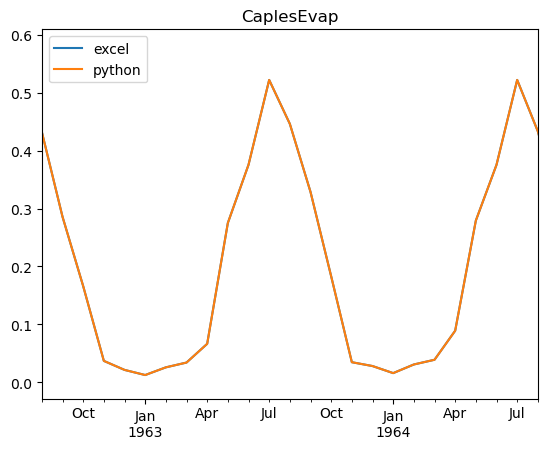

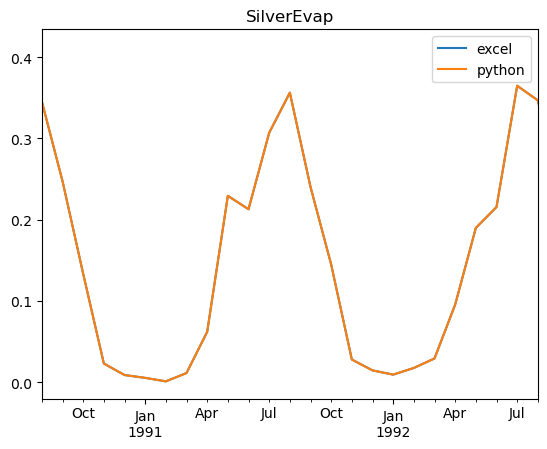

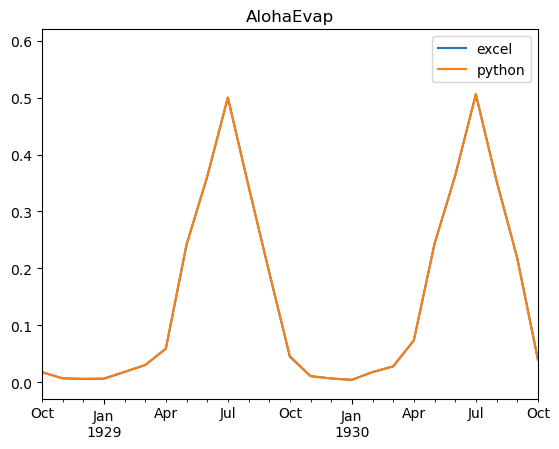

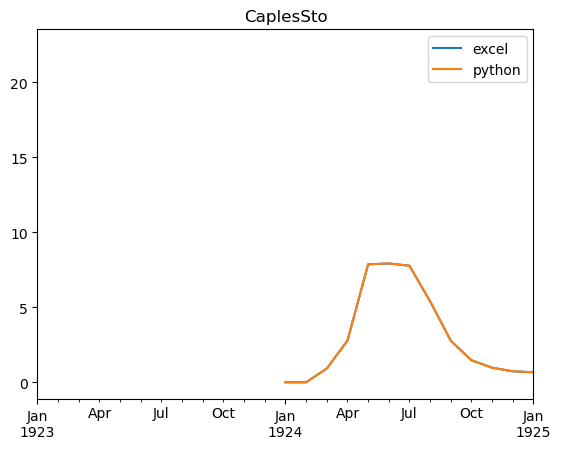

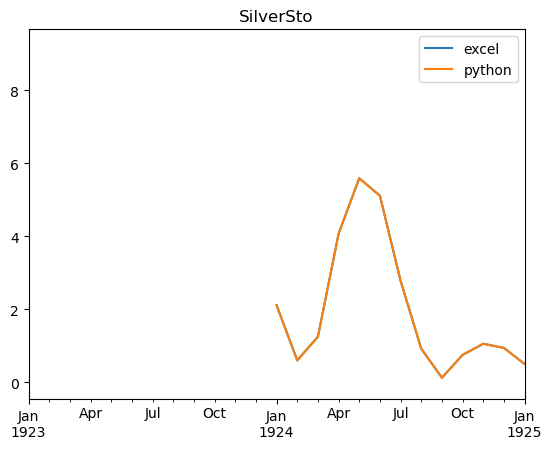

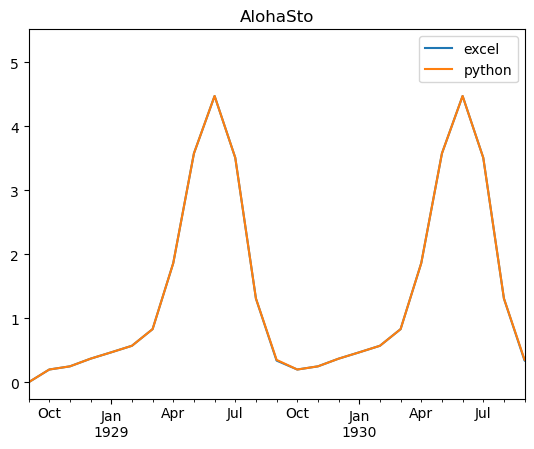

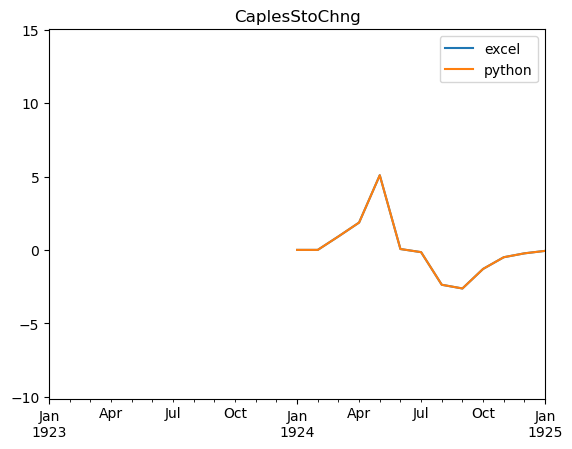

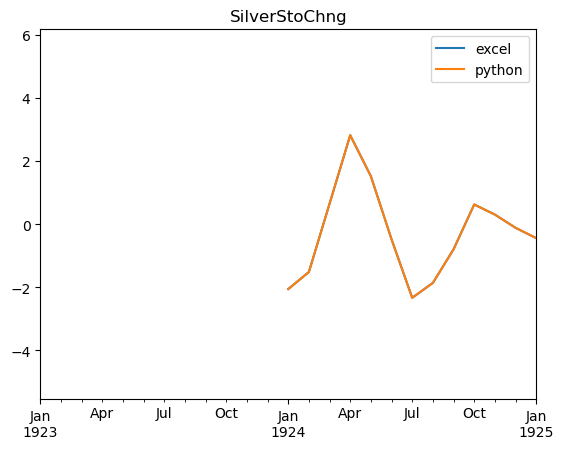

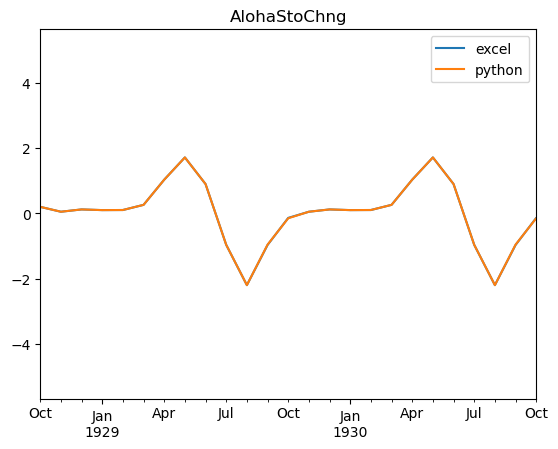

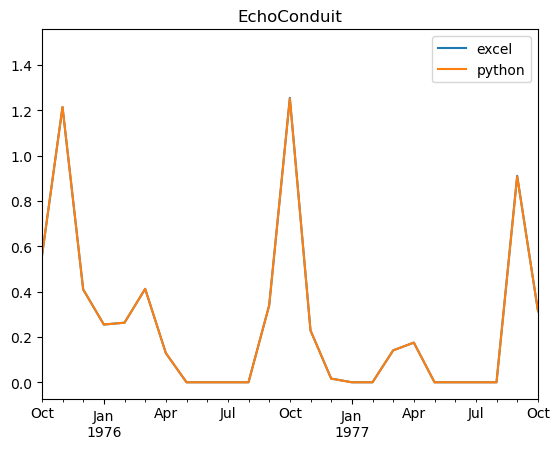

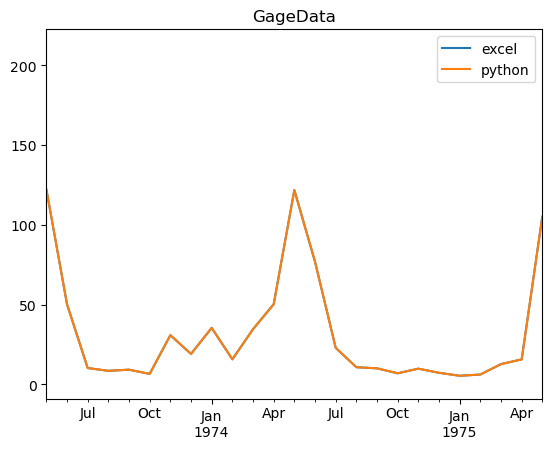

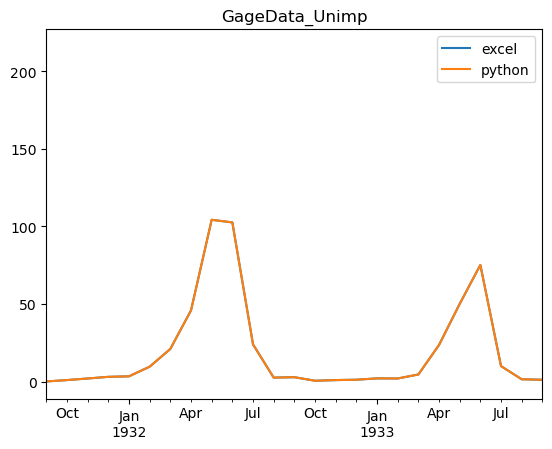

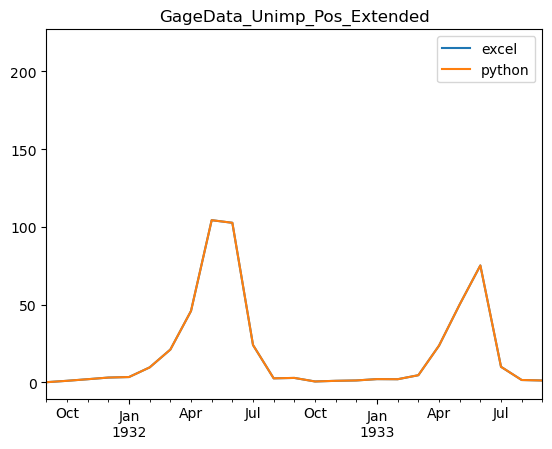

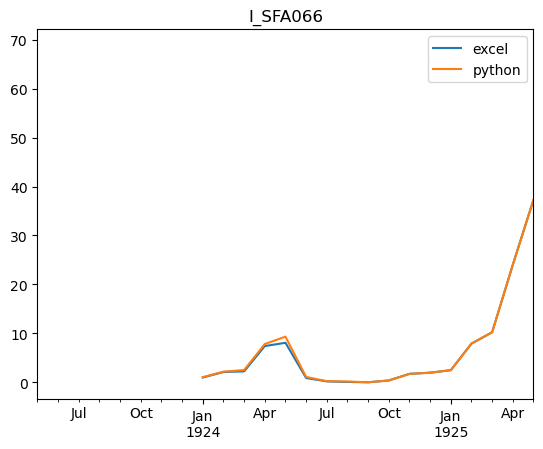

In [13]:
# Recheck after 1923
# Plot a comparison
l_plt_vars =  ['CaplesEvap','SilverEvap','AlohaEvap','CaplesSto','SilverSto','AlohaSto',\
               'CaplesStoChng','SilverStoChng','AlohaStoChng','EchoConduit',\
                'GageData','GageData_Unimp','GageData_Unimp_Pos_Extended','I_SFA066']

for s_plt_var in l_plt_vars:

    df_compare = pd.concat([df_all_unimp_data[s_plt_var],df_excel_all[s_plt_var]],axis=1)
    df_compare.sort_index(inplace=True)

    df_compare = df_compare[df_compare.index >= pd.to_datetime('1924-01-01')]

    df_compare.columns = ['python','excel']
    df_compare['diff'] = abs(df_compare['python'] - df_compare['excel'])
    df_compare['perDiff'] = df_compare['diff'] / df_compare['excel'] * 100


    date_max_error = df_compare[df_compare['diff'] == df_compare['diff'].max()].index[0]

    print(f'Maximum difference for {s_plt_var} is {df_compare['diff'].max()} on {date_max_error}, with a % difference of {df_compare['perDiff'].loc[date_max_error]}')

    #fig,ax = plt.subplots()
    df_compare[['excel','python']].plot()
    plt.title(s_plt_var)
    plt.xlim(date_max_error - pd.DateOffset(years=1),date_max_error + pd.DateOffset(years=1))
    plt.plot()